# GPX1 Discovery Agent — Interview Demo

### A compact scientific learning layer for closed-loop small-molecule discovery

**Core question**

> Can an agent learn when to exploit predicted GPX1 activity and when to explore uncertain chemistry under a fixed experimental budget?

This notebook intentionally tells one end-to-end story:

```text
Real GPX1 activity data
        ↓
RDKit molecular representation
        ↓
Scaffold-aware activity model
        ↓
Closed-loop experiment selection
        ↓
Scientific reward engineering
        ↓
RL meta-policy
        ↓
Evaluation on unseen campaign initializations
```

### Headline result

The RL policy **did not automatically beat pure exploitation**. Instead, the most informative result was that changing the scientific reward changed the agent's behavior—and exposed a mismatch between **uncertainty exploration** and **chemical-novelty exploration**.

That is the central lesson of this demo.

## 1. Setup

The notebook expects the curated CSV:

`GPX1_curated_for_RL.csv`

In Colab, upload it when prompted. The raw dataset is not bundled with the public project until assay provenance is fully documented.

In [1]:
# Uncomment in a fresh Colab runtime if RDKit is unavailable:
# !pip install -q rdkit pandas numpy scikit-learn matplotlib

from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import GroupShuffleSplit

RANDOM_SEED = 42
BUDGET = 40

# Interview-safe default:
# False = quick demonstration run
# True  = exact full protocol used for the reported results
RUN_HEAVY_EXPERIMENTS = False

if RUN_HEAVY_EXPERIMENTS:
    ACTIVE_LEARNING_SEEDS = range(10, 20)
    Q_TRAIN_EPISODES = 40
    FINAL_EVAL_SEEDS = range(60, 80)
    ABLATION_TRAIN_EPISODES = 40
    ABLATION_TEST_SEEDS = range(120, 140)
else:
    ACTIVE_LEARNING_SEEDS = range(10, 13)
    Q_TRAIN_EPISODES = 10
    FINAL_EVAL_SEEDS = range(60, 65)
    ABLATION_TRAIN_EPISODES = 10
    ABLATION_TEST_SEEDS = range(120, 125)

np.random.seed(RANDOM_SEED)

print("Heavy repeated experiments:", "ON" if RUN_HEAVY_EXPERIMENTS else "OFF — using saved full-run reference tables")

# Locate the dataset automatically.
candidates = [
    Path("GPX1_curated_for_RL.csv"),
    Path("/content/GPX1_curated_for_RL.csv"),
    Path("../data/GPX1_curated_for_RL.csv"),
]

DATA_PATH = next((p for p in candidates if p.exists()), None)

if DATA_PATH is None:
    try:
        from google.colab import files
        uploaded = files.upload()
        if "GPX1_curated_for_RL.csv" not in uploaded:
            raise FileNotFoundError("Please upload GPX1_curated_for_RL.csv")
        DATA_PATH = Path("GPX1_curated_for_RL.csv")
    except ImportError as exc:
        raise FileNotFoundError(
            "Place GPX1_curated_for_RL.csv in the working directory."
        ) from exc

print("Using:", DATA_PATH)

Heavy repeated experiments: OFF — using saved full-run reference tables
Using: GPX1_curated_for_RL.csv


### Interview mode

`RUN_HEAVY_EXPERIMENTS = False` is the recommended interview setting.

The notebook still runs the data audit, molecular representation, scaffold split, baseline model, screening enrichment, and defines the full closed-loop/RL implementation. Repeated campaign sweeps and RL retraining are **not rerun live**; instead, the notebook displays the saved results from the full development protocol.

Set `RUN_HEAVY_EXPERIMENTS = True` to rerun the repeated experiments from scratch.

This separation makes the notebook presentation-safe while preserving full reproducibility.

## 2. Data audit: establish the scientific problem

This is a **rare-hit discovery problem**, not a conventional balanced classification task.

Because fewer than 2% of compounds are active, accuracy would be misleading. The evaluation therefore emphasizes:

- PR-AUC
- screening enrichment
- recovered active compounds under a fixed experimental budget
- active scaffold discovery

In [2]:
df = pd.read_csv(DATA_PATH)

summary = pd.Series({
    "Compounds": len(df),
    "Actives": int(df["label"].sum()),
    "Inactives": int((df["label"] == 0).sum()),
    "Active rate": df["label"].mean(),
    "Unique scaffolds": df["scaffold"].nunique(),
    "Missing values": int(df.isna().sum().sum()),
    "Duplicate SMILES": int(
        df["PUBCHEM_EXT_DATASOURCE_SMILES"].duplicated().sum()
    ),
})

display(summary.to_frame("value"))

,value
Compounds,9304.00000
Actives,155.00000
Inactives,9149.00000
Active rate,0.01666
Unique scaffolds,5825.00000
Missing values,0.00000
Duplicate SMILES,0.00000


**Development dataset:** 9,304 compounds, 155 actives, 1.67% active rate, and 5,825 unique scaffolds.

An always-inactive classifier would be ~98% accurate, so **accuracy is not a useful primary metric here**.

## 3. Molecular representation and scaffold-aware baseline

Each SMILES is converted to a 2,048-bit Morgan fingerprint (radius 2).

Instead of a random split, entire molecular scaffolds are held out. This reduces analogue leakage and asks a harder question:

> Can the model generalize to chemistry it has not seen during training?

In [3]:
def parse_smiles(smiles):
    mols = [Chem.MolFromSmiles(str(s)) for s in smiles]
    valid = np.array([m is not None for m in mols], dtype=bool)
    return [m for m in mols if m is not None], valid


def morgan_fingerprints(mols, radius=2, fp_size=2048):
    generator = rdFingerprintGenerator.GetMorganGenerator(
        radius=radius,
        fpSize=fp_size,
    )
    X = np.zeros((len(mols), fp_size), dtype=np.uint8)
    for i, mol in enumerate(mols):
        X[i] = np.asarray(
            generator.GetFingerprintAsNumPy(mol),
            dtype=np.uint8,
        )
    return X


def build_model():
    return LogisticRegression(
        class_weight="balanced",
        max_iter=2500,
        solver="liblinear",
        random_state=RANDOM_SEED,
    )


mols, valid_mask = parse_smiles(
    df["PUBCHEM_EXT_DATASOURCE_SMILES"]
)
clean = df.loc[valid_mask].copy().reset_index(drop=True)

X = morgan_fingerprints(mols)
y = clean["label"].to_numpy(dtype=int)
scaffolds = clean["scaffold"].astype(str).to_numpy()

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_SEED,
)

campaign_idx, validation_idx = next(
    splitter.split(X, y, groups=scaffolds)
)

X_campaign = X[campaign_idx]
y_campaign = y[campaign_idx]
campaign_scaffolds = scaffolds[campaign_idx]

X_validation = X[validation_idx]
y_validation = y[validation_idx]

assert len(
    set(campaign_scaffolds)
    & set(scaffolds[validation_idx])
) == 0

baseline = build_model()
baseline.fit(X_campaign, y_campaign)

p_validation = baseline.predict_proba(X_validation)[:, 1]

roc_auc = roc_auc_score(y_validation, p_validation)
pr_auc = average_precision_score(y_validation, p_validation)
random_pr = y_validation.mean()

print(f"Campaign compounds: {len(campaign_idx):,}")
print(f"Validation compounds: {len(validation_idx):,}")
print("Shared scaffolds: 0")
print()
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")
print(f"Random PR baseline: {random_pr:.3f}")
print(f"PR-AUC enrichment: {pr_auc / random_pr:.1f}x")

Campaign compounds: 7,470
Validation compounds: 1,834
Shared scaffolds: 0

ROC-AUC: 0.813
PR-AUC: 0.309
Random PR baseline: 0.019
PR-AUC enrichment: 16.2x


### Baseline reference result

- **ROC-AUC:** ~0.813  
- **PR-AUC:** ~0.309  
- **Random PR baseline:** ~0.019  
- **PR-AUC enrichment:** ~16.2×

A simple model is intentionally retained as a strong, interpretable baseline before introducing sequential decision-making.

In [4]:
ranked = pd.DataFrame({
    "true_label": y_validation,
    "score": p_validation,
}).sort_values("score", ascending=False)

rows = []
for k in [10, 20, 40, 100]:
    hits = int(ranked.head(k)["true_label"].sum())
    random_expected = k * y_validation.mean()
    rows.append({
        "budget": k,
        "actives_found": hits,
        "random_expected": random_expected,
        "enrichment": hits / random_expected,
    })

screening_table = pd.DataFrame(rows)
display(screening_table.round(3))

,budget,actives_found,random_expected,enrichment
0,10,5,0.191,26.200
1,20,10,0.382,26.200
2,40,13,0.763,17.030
3,100,16,1.908,8.384


At a budget of 40 compounds, the baseline ranking recovered **13 actives** versus ~0.76 expected from random screening.

Now we turn a static ranking problem into a **closed-loop experiment-selection problem**.

## 4. Closed-loop discovery environment

Each simulated campaign begins with a small historical dataset:

- 5 known actives
- 45 known inactives

The remaining labels are hidden.

At each step:

1. train the surrogate on observed experiments,
2. score the remaining pool,
3. choose **EXPLOIT** or **EXPLORE**,
4. reveal the selected compound's true activity,
5. retrain,
6. repeat until the 40-experiment budget is exhausted.

### Actions

- `0 = EXPLOIT` → highest predicted activity
- `1 = EXPLORE` → highest predictive entropy

In [5]:
def create_seed_set(campaign_seed, n_actives=5, n_inactives=45):
    rng = np.random.default_rng(campaign_seed)

    active_candidates = np.where(y_campaign == 1)[0]
    inactive_candidates = np.where(y_campaign == 0)[0]

    seed_active = rng.choice(
        active_candidates,
        size=n_actives,
        replace=False,
    )
    seed_inactive = rng.choice(
        inactive_candidates,
        size=n_inactives,
        replace=False,
    )

    seed_idx = np.concatenate([seed_active, seed_inactive])
    rng.shuffle(seed_idx)

    pool_idx = np.setdiff1d(
        np.arange(len(y_campaign)),
        seed_idx,
    )
    return seed_idx, pool_idx


def fit_surrogate(labeled_idx):
    model = build_model()
    model.fit(
        X_campaign[np.asarray(labeled_idx)],
        y_campaign[np.asarray(labeled_idx)],
    )
    return model


def binary_entropy(probabilities):
    p = np.clip(
        np.asarray(probabilities),
        1e-8,
        1 - 1e-8,
    )
    return -(
        p * np.log2(p)
        + (1 - p) * np.log2(1 - p)
    )


class GPX1DiscoveryEnv:

    def __init__(
        self,
        budget=40,
        activity_reward=2.0,
        novelty_reward=1.0,
        information_reward=0.5,
        information_scale=100.0,
        recent_window=5,
    ):
        self.budget = budget
        self.activity_reward = activity_reward
        self.novelty_reward = novelty_reward
        self.information_reward = information_reward
        self.information_scale = information_scale
        self.recent_window = recent_window

    def reset(self, campaign_seed):
        self.seed_idx, pool_idx = create_seed_set(campaign_seed)

        self.labeled = list(self.seed_idx.copy())
        self.available = list(pool_idx.copy())
        self.history = []
        self.step_count = 0

        seed_active_idx = self.seed_idx[
            y_campaign[self.seed_idx] == 1
        ]
        self.known_active_scaffolds = set(
            campaign_scaffolds[seed_active_idx]
        )

        self.model = fit_surrogate(self.labeled)
        return self._observation()

    def _observation(self):
        progress = self.step_count / self.budget

        if self.history:
            observed = [
                h["observed_label"]
                for h in self.history
            ]
            cumulative_hit_rate = float(np.mean(observed))
            recent_hit_rate = float(
                np.mean(observed[-self.recent_window:])
            )
        else:
            cumulative_hit_rate = 0.0
            recent_hit_rate = 0.0

        if self.available:
            p = self.model.predict_proba(
                X_campaign[self.available]
            )[:, 1]
            mean_pool_entropy = float(
                binary_entropy(p).mean()
            )
        else:
            mean_pool_entropy = 0.0

        labeled = np.asarray(self.labeled)
        active_idx = labeled[
            y_campaign[labeled] == 1
        ]
        scaffold_diversity = (
            len(set(campaign_scaffolds[active_idx]))
            / len(active_idx)
            if len(active_idx)
            else 0.0
        )

        return np.array(
            [
                progress,
                cumulative_hit_rate,
                recent_hit_rate,
                mean_pool_entropy,
                scaffold_diversity,
            ],
            dtype=np.float32,
        )

    def step(self, action):
        p = self.model.predict_proba(
            X_campaign[self.available]
        )[:, 1]
        entropy = binary_entropy(p)

        selected_position = (
            int(np.argmax(p))
            if action == 0
            else int(np.argmax(entropy))
        )

        selected_idx = self.available[selected_position]
        selected_scaffold = campaign_scaffolds[selected_idx]

        keep = np.ones(len(self.available), dtype=bool)
        keep[selected_position] = False
        entropy_before = (
            float(entropy[keep].mean())
            if keep.any()
            else 0.0
        )

        observed_label = int(y_campaign[selected_idx])

        novel_active_scaffold = int(
            observed_label == 1
            and selected_scaffold
            not in self.known_active_scaffolds
        )

        self.labeled.append(selected_idx)
        self.available.remove(selected_idx)

        if observed_label == 1:
            self.known_active_scaffolds.add(
                selected_scaffold
            )

        self.model = fit_surrogate(self.labeled)

        if self.available:
            p_after = self.model.predict_proba(
                X_campaign[self.available]
            )[:, 1]
            entropy_after = float(
                binary_entropy(p_after).mean()
            )
        else:
            entropy_after = 0.0

        information_gain = (
            entropy_before - entropy_after
        )
        scaled_information_gain = float(
            np.tanh(
                self.information_scale
                * information_gain
            )
        )

        reward = (
            self.activity_reward * observed_label
            + self.novelty_reward
            * novel_active_scaffold
            + self.information_reward
            * scaled_information_gain
        )

        self.step_count += 1

        info = {
            "step": self.step_count,
            "action": action,
            "selected_index": selected_idx,
            "observed_label": observed_label,
            "novel_active_scaffold":
                novel_active_scaffold,
            "information_gain": information_gain,
            "scaled_information_gain":
                scaled_information_gain,
            "reward": reward,
        }

        self.history.append(info)

        done = self.step_count >= self.budget
        return self._observation(), reward, done, info

## 5. Active-learning baseline: exploration vs exploitation

Before training RL, compare simple fixed policies.

**Why this matters:** RL should only be added if a state-dependent policy has a plausible advantage over strong hand-designed baselines.

In [6]:
if RUN_HEAVY_EXPERIMENTS:
    epsilon_rows = []

    for epsilon in [0.0, 0.1, 0.2, 0.3, 0.5, 1.0]:
        for campaign_seed in ACTIVE_LEARNING_SEEDS:
            metrics = run_fixed_policy(
                campaign_seed,
                epsilon,
            )
            epsilon_rows.append({
                "epsilon": epsilon,
                **metrics,
            })

    epsilon_results = pd.DataFrame(
        epsilon_rows
    )

    epsilon_summary = (
        epsilon_results
        .groupby("epsilon")
        .agg(
            mean_hits=("hits", "mean"),
            hit_sd=("hits", "std"),
            mean_active_scaffolds=(
                "active_scaffolds",
                "mean",
            ),
            mean_validation_pr_auc=(
                "validation_pr_auc",
                "mean",
            ),
        )
        .reset_index()
    )
else:
    # Saved results from the full 10-seed development sweep.
    epsilon_summary = pd.DataFrame({
        "epsilon": [0.0, 0.1, 0.2, 0.3, 0.5, 1.0],
        "mean_hits": [31.7, 30.7, 28.7, 26.2, 21.6, 5.6],
        "hit_sd": [10.802, 10.467, 9.832, 9.211, 6.899, 1.350],
        "mean_active_scaffolds": [21.8, 21.3, 19.9, 18.0, 15.7, 5.6],
        "mean_validation_pr_auc": [0.212911, 0.210504, 0.214887, 0.217739, 0.222856, 0.230338],
    })

display(epsilon_summary.round(3))

,epsilon,mean_hits,hit_sd,mean_active_scaffolds,mean_validation_pr_auc
0,0.0,31.7,10.802,21.8,0.213
1,0.1,30.7,10.467,21.3,0.211
2,0.2,28.7,9.832,19.9,0.215
3,0.3,26.2,9.211,18.0,0.218
4,0.5,21.6,6.899,15.7,0.223
5,1.0,5.6,1.350,5.6,0.230


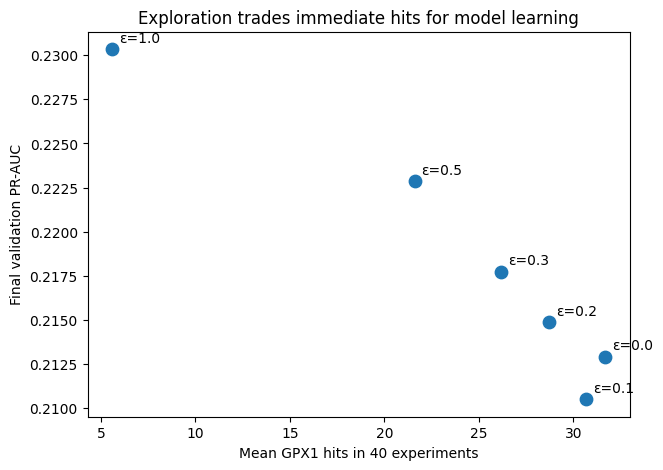

In [7]:
# Compact visual: immediate discovery vs final model quality.

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    epsilon_summary["mean_hits"],
    epsilon_summary["mean_validation_pr_auc"],
    s=80,
)

for _, row in epsilon_summary.iterrows():
    ax.annotate(
        f'ε={row["epsilon"]}',
        (
            row["mean_hits"],
            row["mean_validation_pr_auc"],
        ),
        xytext=(5, 5),
        textcoords="offset points",
    )

ax.set_xlabel("Mean GPX1 hits in 40 experiments")
ax.set_ylabel("Final validation PR-AUC")
ax.set_title(
    "Exploration trades immediate hits for model learning"
)
plt.show()

### Development result

Increasing ε moves the campaign away from immediate hit discovery and toward model learning.

In the development sweep, **ε = 0.0 (pure exploitation)** was strongest for hit recovery, while pure uncertainty sampling produced the highest final validation PR-AUC.

This creates the reward-design question:

> What should count as a scientifically valuable experiment?

## 6. Scientific reward engineering

The rubric separates three concepts:

1. **Activity** — did the experiment find an active compound?
2. **Chemical novelty** — did an active compound introduce a new scaffold?
3. **Information value** — did the experiment reduce predictive entropy across the remaining pool?

A reward-scale audit showed that raw information gain was only around 0.001–0.004, while activity contributed +2.

Without rescaling, the RL agent would effectively be unable to “see” information gain.

The bounded transformation is:

\[
I_{scaled} = \tanh(100 I)
\]

and the initial reward is:

\[
R = 2H + N + 0.5I_{scaled}
\]

This keeps **activity > novelty > information**, while allowing all three signals to matter numerically.

## 7. Q-learning meta-policy

The RL agent observes:

1. campaign progress
2. cumulative hit rate
3. recent hit rate
4. mean pool entropy
5. active scaffold diversity

It then chooses:

- **EXPLOIT**
- **EXPLORE**

A tabular Q-learner is intentionally used first because the action space is tiny and interpretability is valuable. More complex policy optimization should come only after the environment and reward are validated.

In [8]:
INITIAL_REWARD = {
    "activity_reward": 2.0,
    "novelty_reward": 1.0,
    "information_reward": 0.5,
}

if RUN_HEAVY_EXPERIMENTS:
    Q_initial, training_history = train_q_agent(
        INITIAL_REWARD,
        n_episodes=Q_TRAIN_EPISODES,
        starting_seed=20,
    )

    training_summary = pd.Series({
        "States learned": len(Q_initial),
        "Mean reward — first 10": training_history["total_reward"].head(10).mean(),
        "Mean reward — last 10": training_history["total_reward"].tail(10).mean(),
        "Mean hits — first 10": training_history["hits"].head(10).mean(),
        "Mean hits — last 10": training_history["hits"].tail(10).mean(),
        "Mean explore actions — first 10": training_history["explore_actions"].head(10).mean(),
        "Mean explore actions — last 10": training_history["explore_actions"].tail(10).mean(),
    })
else:
    Q_initial = None
    training_history = None

    # Saved results from the full 40-episode training run.
    training_summary = pd.Series({
        "States learned": 72,
        "Mean reward — first 10": 60.001,
        "Mean reward — last 10": 83.136,
        "Mean hits — first 10": 20.0,
        "Mean hits — last 10": 29.4,
        "Mean explore actions — first 10": 19.5,
        "Mean explore actions — last 10": 8.4,
    })

display(training_summary.to_frame("value").round(3))

,value
States learned,72.000
Mean reward — first 10,60.001
Mean reward — last 10,83.136
Mean hits — first 10,20.000
Mean hits — last 10,29.400
Mean explore actions — first 10,19.500
Mean explore actions — last 10,8.400


**Reference training behavior**

- Q-table states learned: ~72
- mean reward increased from ~60 to ~83
- mean hits increased from ~20 to ~29.4

Because training ε is annealed, these training curves alone do **not** establish that RL learned a superior policy. The real test is frozen-policy evaluation on unseen campaign initializations.

## 8. Frozen-policy evaluation

Evaluation uses campaign seeds that were not used during Q-learning.

The key comparison is:

- pure exploitation
- pure exploration
- frozen Q-policy

The Q-table is not updated during evaluation.

In [9]:
if RUN_HEAVY_EXPERIMENTS:
    rows = []

    for campaign_seed in FINAL_EVAL_SEEDS:
        for name, mode in [
            ("Pure Exploitation", "exploit"),
            ("Pure Exploration", "explore"),
            ("Q-Learning", "q"),
        ]:
            metrics = evaluate_policy(
                campaign_seed,
                mode,
                Q=Q_initial,
            )
            rows.append({
                "strategy": name,
                "campaign": campaign_seed,
                **metrics,
            })

    final_results = pd.DataFrame(rows)

    final_summary = (
        final_results
        .groupby("strategy")
        .agg(
            mean_reward=("total_reward", "mean"),
            reward_sd=("total_reward", "std"),
            mean_hits=("hits", "mean"),
            hit_sd=("hits", "std"),
            mean_active_scaffolds=("active_scaffolds", "mean"),
            mean_validation_pr_auc=("validation_pr_auc", "mean"),
            mean_explore_actions=("explore_actions", "mean"),
            mean_q_state_coverage=("q_state_coverage", "mean"),
        )
        .reset_index()
    )
else:
    # Saved results from 20 unseen campaign initializations.
    final_summary = pd.DataFrame({
        "strategy": ["Pure Exploitation", "Q-Learning", "Pure Exploration"],
        "mean_reward": [94.579807, 90.233382, 27.366522],
        "reward_sd": [18.903954, 18.176072, 4.802085],
        "mean_hits": [33.90, 31.90, 6.75],
        "hit_sd": [7.552622, 7.224957, 1.860249],
        "mean_active_scaffolds": [23.6, 22.5, 6.7],
        "mean_validation_pr_auc": [0.221212, 0.224462, 0.240142],
        "mean_explore_actions": [0.0, 4.6, 40.0],
        "mean_q_state_coverage": [np.nan, 1.0, np.nan],
    })

display(final_summary.round(3))

,strategy,mean_reward,reward_sd,mean_hits,hit_sd,mean_active_scaffolds,mean_validation_pr_auc,mean_explore_actions,mean_q_state_coverage
0,Pure Exploitation,94.580,18.904,33.90,7.553,23.6,0.221,0.0,NaN
1,Q-Learning,90.233,18.176,31.90,7.225,22.5,0.224,4.6,1.0
2,Pure Exploration,27.367,4.802,6.75,1.860,6.7,0.240,40.0,NaN


### Final policy result

Reference result from the development run:

| Strategy | Mean reward | Mean hits | Active scaffolds | Validation PR-AUC |
|---|---:|---:|---:|---:|
| Pure exploitation | **94.58** | **33.9** | **23.6** | 0.221 |
| Q-learning | 90.23 | 31.9 | 22.5 | **0.224** |
| Pure exploration | 27.37 | 6.75 | 6.7 | 0.240 |

**Interpretation:** under this hit-heavy reward, pure exploitation remains the strongest strategy. RL is not automatically better than a strong hand-designed baseline.

## 9. Reward ablation: does the scientific objective change behavior?

Three scientific objectives are tested:

- **Hit-Centric:** `2 × activity`
- **Diversity-Aware:** `2 × activity + 2 × novel active scaffold`
- **Learning-Balanced:** `2 × activity + 1 × novel scaffold + 1 × scaled information gain`

The goal is not to compare reward magnitudes across objectives. The goal is to ask whether **reward specification changes policy behavior and downstream scientific outcomes**.

In [10]:
REWARD_CONFIGS = {
    "Hit-Centric": {
        "activity_reward": 2.0,
        "novelty_reward": 0.0,
        "information_reward": 0.0,
    },
    "Diversity-Aware": {
        "activity_reward": 2.0,
        "novelty_reward": 2.0,
        "information_reward": 0.0,
    },
    "Learning-Balanced": {
        "activity_reward": 2.0,
        "novelty_reward": 1.0,
        "information_reward": 1.0,
    },
}

reward_agents = {}

if RUN_HEAVY_EXPERIMENTS:
    for name, config in REWARD_CONFIGS.items():
        Q_agent, _ = train_q_agent(
            config,
            n_episodes=ABLATION_TRAIN_EPISODES,
            starting_seed=80,
        )
        reward_agents[name] = Q_agent
else:
    print("Using saved full-run reward-ablation results.")

Using saved full-run reward-ablation results.


In [11]:
if RUN_HEAVY_EXPERIMENTS:
    rows = []

    for name, Q_agent in reward_agents.items():
        for campaign_seed in ABLATION_TEST_SEEDS:
            metrics = evaluate_policy(
                campaign_seed,
                mode="q",
                Q=Q_agent,
                reward_config=REWARD_CONFIGS[name],
            )
            rows.append({
                "objective": name,
                "campaign": campaign_seed,
                **metrics,
            })

    reward_ablation = pd.DataFrame(rows)

    reward_summary = (
        reward_ablation
        .groupby("objective")
        .agg(
            mean_hits=("hits", "mean"),
            hit_sd=("hits", "std"),
            mean_active_scaffolds=("active_scaffolds", "mean"),
            mean_validation_pr_auc=("validation_pr_auc", "mean"),
            mean_explore_actions=("explore_actions", "mean"),
        )
        .reset_index()
    )
else:
    # Saved results from the full 20-campaign evaluation per objective.
    reward_summary = pd.DataFrame({
        "objective": [
            "Diversity-Aware",
            "Hit-Centric",
            "Learning-Balanced",
        ],
        "mean_hits": [32.00, 33.30, 31.15],
        "hit_sd": [7.203800, 7.609551, 7.058217],
        "mean_active_scaffolds": [22.35, 23.05, 21.70],
        "mean_validation_pr_auc": [0.219676, 0.218111, 0.221160],
        "mean_explore_actions": [4.70, 0.70, 5.45],
    })

display(reward_summary.round(3))

,objective,mean_hits,hit_sd,mean_active_scaffolds,mean_validation_pr_auc,mean_explore_actions
0,Diversity-Aware,32.00,7.204,22.35,0.220,4.70
1,Hit-Centric,33.30,7.610,23.05,0.218,0.70
2,Learning-Balanced,31.15,7.058,21.70,0.221,5.45


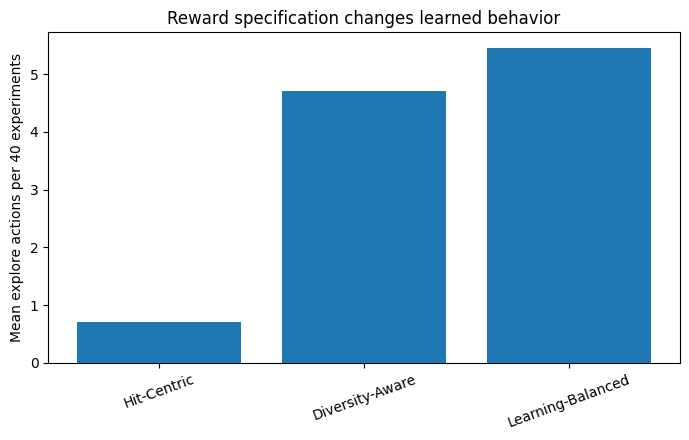

In [12]:
fig, ax = plt.subplots(figsize=(7, 4.5))

ordered = reward_summary.sort_values(
    "mean_explore_actions"
)

ax.bar(
    ordered["objective"],
    ordered["mean_explore_actions"],
)

ax.set_ylabel("Mean explore actions per 40 experiments")
ax.set_title("Reward specification changes learned behavior")
ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

### Reward-ablation reference result

| Objective | Mean hits | Active scaffolds | Validation PR-AUC | Explore actions |
|---|---:|---:|---:|---:|
| Hit-Centric | **33.30** | **23.05** | 0.218 | 0.70 |
| Diversity-Aware | 32.00 | 22.35 | 0.220 | 4.70 |
| Learning-Balanced | 31.15 | 21.70 | **0.221** | **5.45** |

### Most important design insight

Rewarding scaffold novelty made the policy explore more, but did **not** increase active scaffold discovery.

Why?

Because the available exploration action chooses **maximum predictive uncertainty**, not **maximum chemical novelty**.

Therefore:

> **Reward design and action-space design are separate problems.**

A stronger next version would add an explicit scaffold-diversity or molecular-distance action.

# 10. Interview takeaways

### What worked
- Real GPX1 screening data produced meaningful molecular signal.
- Scaffold-aware evaluation reduced analogue leakage.
- Simple exploitation was an unexpectedly strong baseline.
- Reward scaling materially changed what the RL agent could learn.
- Different reward formulations produced different policy behavior.

### What did not work
- RL did not beat exploitation under a hit-heavy objective.
- Uncertainty exploration did not guarantee scaffold novelty.
- Decision uncertainty from logistic-regression scores is not rigorous epistemic uncertainty.

### What I would do next
1. Replace score-based uncertainty with bootstrap/ensemble disagreement.
2. Add an explicit chemical-diversity exploration action.
3. Move from binary activity to potency and multi-endpoint objectives.
4. Add experiment cost, assay noise, and batch selection.
5. Establish a new untouched scaffold-disjoint final test set.
6. Only then consider PPO or a neural value function if the richer state/action space justifies it.

### One-sentence summary

> I built a closed-loop GPX1 discovery simulator that uses molecular ML to propose experiments and reinforcement learning to study how scientific reward design changes exploration-versus-exploitation behavior.